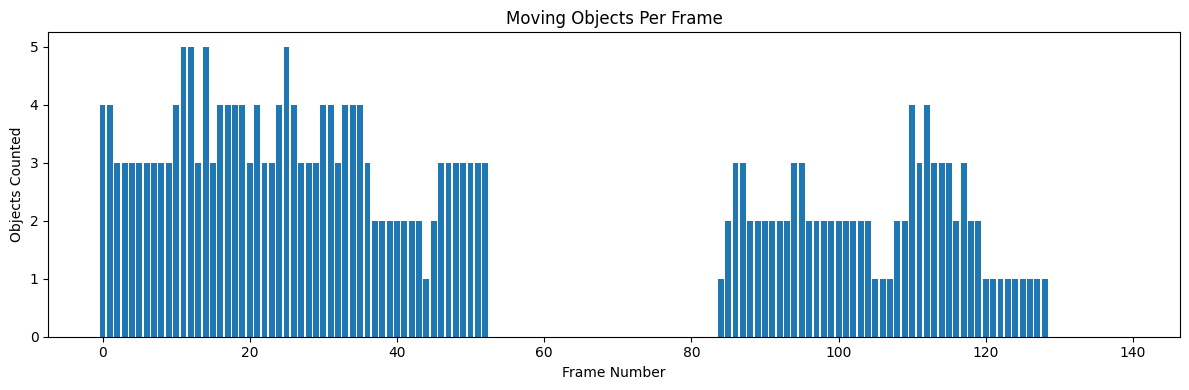

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

# ------------------------------------------------------
# Helper: load specific frame number
# ------------------------------------------------------
def load_frame(cap, n):
    cap.set(cv2.CAP_PROP_POS_FRAMES, n)
    ok, frame = cap.read()
    if not ok:
        raise ValueError(f"Could not read frame {n}")
    return frame

# ------------------------------------------------------
# Load video
# ------------------------------------------------------
cap = cv2.VideoCapture("DatasetC.avi")
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# ------------------------------------------------------
# 5(a) – Reference frame differencing
# ------------------------------------------------------

ref = load_frame(cap, 0)
frame29 = load_frame(cap, 29)
frame30 = load_frame(cap, 30)
frame89 = load_frame(cap, 89)
frame90 = load_frame(cap, 90)

# Save required original frames
cv2.imwrite("outputs/5_ref.png", ref)
cv2.imwrite("outputs/5_f29.png", frame29)
cv2.imwrite("outputs/5_f30.png", frame30)
cv2.imwrite("outputs/5_f89.png", frame89)
cv2.imwrite("outputs/5_f90.png", frame90)

# Frame differences
diff30 = cv2.absdiff(ref, frame30)
diff90 = cv2.absdiff(ref, frame90)

cv2.imwrite("outputs/5_diff30.png", diff30)
cv2.imwrite("outputs/5_diff90.png", diff90)

# Thresholding
T = 25
gray30 = diff30.mean(axis=2).astype(np.uint8)
gray90 = diff90.mean(axis=2).astype(np.uint8)

_, th30 = cv2.threshold(gray30, T, 255, cv2.THRESH_BINARY)
_, th90 = cv2.threshold(gray90, T, 255, cv2.THRESH_BINARY)

cv2.imwrite("outputs/5_th30.png", th30)
cv2.imwrite("outputs/5_th90.png", th90)

# ------------------------------------------------------
# 5(b) – Previous frame differencing
# ------------------------------------------------------

diff_prev30 = cv2.absdiff(frame29, frame30)
diff_prev90 = cv2.absdiff(frame89, frame90)

cv2.imwrite("outputs/5_diff_prev30.png", diff_prev30)
cv2.imwrite("outputs/5_diff_prev90.png", diff_prev90)

gray_prev30 = diff_prev30.mean(axis=2).astype(np.uint8)
gray_prev90 = diff_prev90.mean(axis=2).astype(np.uint8)

_, th_prev30 = cv2.threshold(gray_prev30, T, 255, cv2.THRESH_BINARY)
_, th_prev90 = cv2.threshold(gray_prev90, T, 255, cv2.THRESH_BINARY)

cv2.imwrite("outputs/5_th_prev30.png", th_prev30)
cv2.imwrite("outputs/5_th_prev90.png", th_prev90)

# ------------------------------------------------------
# 5(c) – Background estimation (temporal averaging)
# ------------------------------------------------------

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
alpha = 0.02
background = None

for i in range(frame_count):
    ok, f = cap.read()
    if not ok:
        break
    f = f.astype(float)

    if background is None:
        background = f
    else:
        background = (1 - alpha) * background + alpha * f

background_img = background.astype(np.uint8)
cv2.imwrite("outputs/5_background.png", background_img)

# ------------------------------------------------------
# 5(d) – Object counting
# ------------------------------------------------------

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
object_counts = []

for i in range(frame_count):
    ok, frame = cap.read()
    if not ok:
        break

    diff = cv2.absdiff(frame, background_img)
    gray = diff.mean(axis=2).astype(np.uint8)
    _, th = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)

    # remove noise
    clean = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)
    areas = stats[1:, cv2.CC_STAT_AREA]
    BIG = areas[areas > 150]

    object_counts.append(len(BIG))

# Save bar plot
plt.figure(figsize=(12,4))
plt.bar(range(len(object_counts)), object_counts)
plt.xlabel("Frame Number")
plt.ylabel("Objects Counted")
plt.title("Moving Objects Per Frame")
plt.tight_layout()
plt.savefig("outputs/5_counts.png", dpi=300)
plt.show()